In [65]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

In [66]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
level = 'midbrain'

cst_wm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_WM', f'summary_MNISymC_CST_{level}_WM_mod.tsv'), sep = '\t')
cerebel_gm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')

# just patients
cst_wm = cst_wm[cst_wm.isPatient == 1]
cerebel_gm = cerebel_gm[cerebel_gm.isPatient == 1]

cerebel_gm = cerebel_gm[cerebel_gm.regionname.isin(regions)]

cst_wm['hemisphere'] = np.where(cst_wm.group == 'ipsilesional', 'R', 'L')
cerebel_gm['hemisphere'] = cerebel_gm.regionname.str[2]



# weeks to correlate
cst_week = 0
cerebel_week = 0

In [ ]:
# affected: ipsilesional CST, contralesional cerebellum

right_cst = cst_wm[(cst_wm.hemisphere == 'R') & (cst_wm.Week == cst_week)] # ipsilesional CST
left_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'L') & (cerebel_gm.Week == cerebel_week)] # contralesional cerebellum
aff_df = pd.merge(right_cst, left_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (6,4))
sns.scatterplot(x = aff_df['mean_cst'], y = aff_df['mean_cerebel'], hue = aff_df['regionname_cerebel'], alpha = .7, ax = ax)
# add best fit line for each region individually
for region in aff_df.regionname_cerebel.unique():
    sns.regplot(data = aff_df[aff_df.regionname_cerebel == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel(f'ipsilesional CST {level} WMV, W{cst_week}')
plt.ylabel(f'contralesional cerebellar ROI GMV, W{cerebel_week}')
plt.title("Affected correlations")

sns.despine(trim = True)
plt.show()

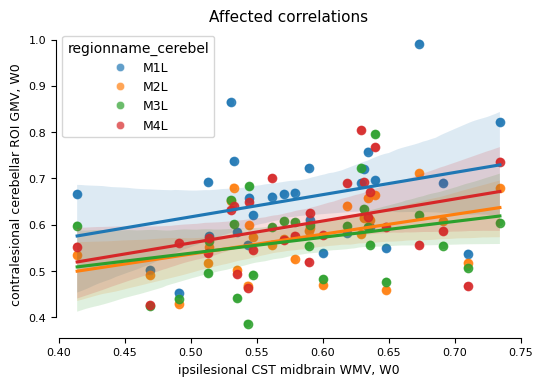

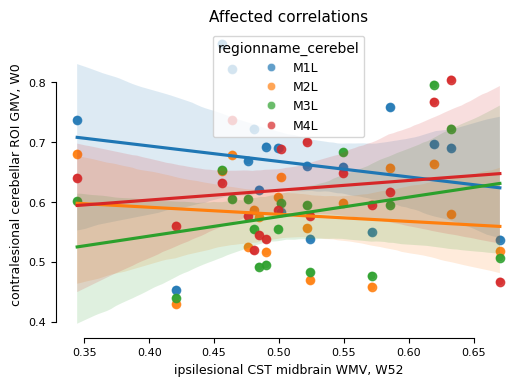